# SHAP_Feature_Interaction

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import shap
import warnings

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
my_seed = 42

warnings.filterwarnings("ignore")

In [3]:
n = 1000
X = pd.DataFrame({
    'x1': np.random.uniform(140, 200, n),
    'x2': np.random.uniform(0, 10, n)
})

In [4]:
y = 0.1 * X.x1 - X.x2 + 10 * (X.x1 < 160) * (X.x2 > 7) - 8

## Data Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=my_seed)

## Model Generation

In [8]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=my_seed)
rf_model = rf_model.fit(X_train, y_train)

The model is now generated

## Model Visualization 

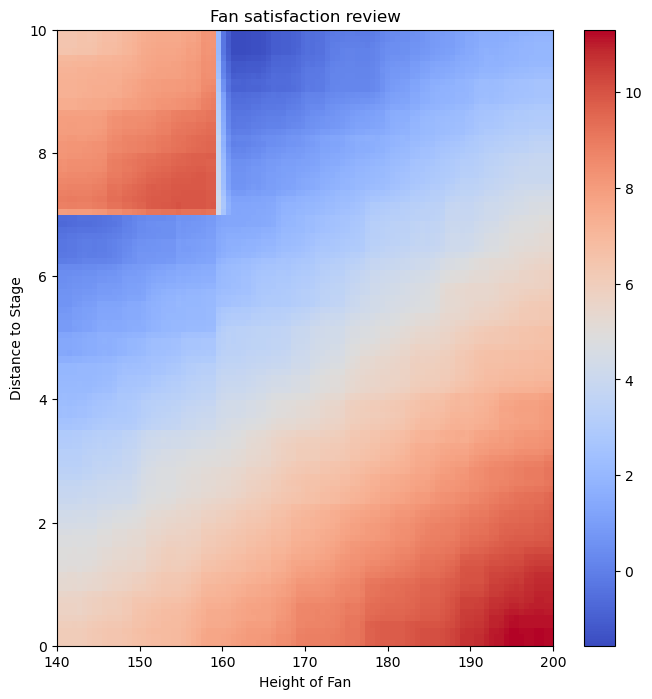

In [11]:
# Generate x1 and x2 grids
x1 = np.linspace(140, 200, 100)
x2 = np.linspace(0, 10, 100)
xx1, xx2 = np.meshgrid(x1, x2)
Xgrid = np.column_stack((xx1.ravel(), xx2.ravel()))
color = rf_model.predict(Xgrid)
color = color.reshape(xx1.shape)

plt.figure(figsize=(8,8), dpi=100)
plt.imshow(color, 
           extent=[x1.min(), x1.max(), x2.min(), x2.max()], 
           origin='lower', 
           cmap='coolwarm', 
           aspect='auto')
plt.title('Fan satisfaction review')
plt.xlabel('Height of Fan')
plt.ylabel('Distance to Stage')
plt.colorbar()
plt.show()

## Computing SHAP Values

In [13]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)

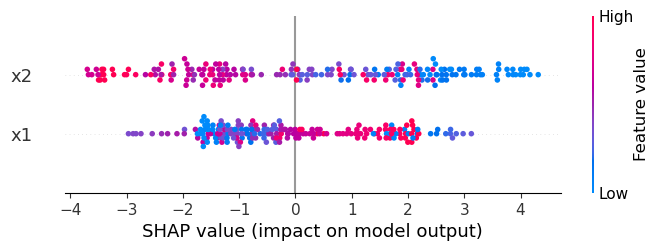

In [14]:
shap.plots.beeswarm(shap_values)

## Dependence Plot

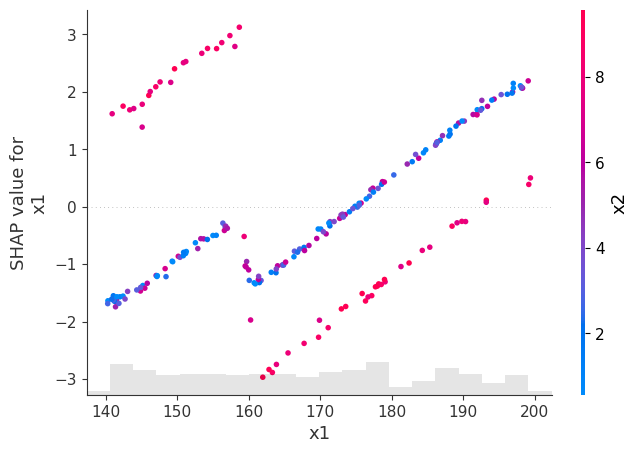

In [16]:
shap.plots.scatter(shap_values[:,0], color=shap_values)

## SHAP Global Component

In [18]:
Xnew = pd.DataFrame({'x1': [159, 161], 'x2': [2,2]})

In [19]:
mia = round(rf_model.predict(Xnew)[0], 2),
tom = round(rf_model.predict(Xnew)[1], 2),
exp = round(explainer.expected_value[0], 2)

print(f"Mia: {mia}")
print(f"Tom: {tom}")
print(f"Expected: {exp}")


Mia: (5.88,)
Tom: (6.07,)
Expected: 4.86


In [20]:
print('Mia')
print(shap_values[0].values)

Mia
[-2.83286243 -3.03710854]


In [21]:
print('Tom')
print(shap_values[1].values)

Tom
[1.40382527 2.78525493]
